## **Setup & Imports**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

rng = np.random.default_rng(2024)
plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## **Exercise 1**

**Part 1 - Quantile Types**

In [2]:
x_demo = np.array([0, 1, 1, 1, 2, 2, 2, 4, 5, 8], dtype=float)

hf_types = ['inverted_cdf', 'averaged_inverted_cdf', 'closest_observation',
            'interpolated_inverted_cdf', 'hazen', 'weibull', 'linear',
            'median_unbiased', 'normal_unbiased']

rows = []

for i, t in enumerate(hf_types, start=1):
    q1, q3 = np.percentile(x_demo, [25, 75], method=t)
    rows.append([i, t, q1, q3.round(3)])

quantile_types = pd.DataFrame(rows, columns=['Type', 'Method', 'Q1', 'Q3'])
quantile_types.to_csv('assets/1.csv', index=False)
quantile_types

,Type,Method,Q1,Q3
0,1,inverted_cdf,1.0,4.000
1,2,averaged_inverted_cdf,1.0,4.000
2,3,closest_observation,1.0,4.000
3,4,interpolated_inverted_cdf,1.0,3.000
4,5,hazen,1.0,4.000
5,6,weibull,1.0,4.250
6,7,linear,1.0,3.500
7,8,median_unbiased,1.0,4.083
8,9,normal_unbiased,1.0,4.062


**Part 2 - Bootstrap Bias Correction**

In [3]:
def lambda_ml(x, axis=-1):
    return 1 / np.mean(x, axis=axis)

def lambda_iqr(x, axis=-1):
    q1, q3 = np.quantile(x, [0.25, 0.75], axis=axis)
    
    with np.errstate(divide='ignore', invalid='ignore'):
        return np.log(3) / (q3 - q1)

def lambda_iqr_bc(x, B=200, rng=rng):
    n = len(x)
    theta = lambda_iqr(x)
    boot = lambda_iqr(x[rng.integers(0, n, (B, n))], axis=1)
    boot = boot[np.isfinite(boot)]
    bias = boot.mean() - theta if len(boot) else 0

    return theta - bias

**Part 3 - Monte Carlo Comparison**

In [4]:
def mc_mse(lam, n, M=2000, B=200):
    X = rng.exponential(1 / lam, size=(M, n))
    ml  = lambda_ml(X, axis=1)
    iqr = lambda_iqr(X, axis=1)
    bc  = np.array([lambda_iqr_bc(x, B) for x in X])

    def mse_se(est):
        sq = (est - lam) ** 2
        return sq.mean(), sq.std(ddof=1) / np.sqrt(M)

    return mse_se(ml), mse_se(iqr), mse_se(bc)

rows = []
for lam in [0.1, 1, 10]:
    for n in [5, 30, 100]:
        (mse_ml, se_ml), (mse_iqr, se_iqr), (mse_bc, se_bc) = mc_mse(lam, n)
        rows.append([lam, n, mse_ml, se_ml, mse_iqr, se_iqr, mse_bc, se_bc])

results = pd.DataFrame(rows, columns=['lambda', 'n', 'MSE_ML', 'SE_ML', 'MSE_IQR', 'SE_IQR', 'MSE_BC', 'SE_BC'])
pd.set_option('display.float_format', lambda v: f'{v:,.5g}')
results.to_csv('assets/2.csv', index=False)
results

,lambda,n,MSE_ML,SE_ML,MSE_IQR,SE_IQR,MSE_BC,SE_BC
0,0.1,5,0.0069069,0.00087277,0.1969,0.03654,"1,738","1,708.5"
1,0.1,30,0.00038802,1.7516e-05,0.0012684,6.4398e-05,0.0013722,7.2729e-05
2,0.1,100,0.00010417,3.5275e-06,0.00024897,9.377e-06,0.00028786,1.0787e-05
3,1,5,0.59909,0.062738,15.884,2.8205,2.4587e+06,2.4426e+06
4,1,30,0.041277,0.0018481,0.13598,0.0087025,0.14374,0.0097878
5,1,100,0.01128,0.00040899,0.0257,0.00099239,0.02972,0.0010868
6,10,5,56.273,4.2284,"2,655.9",513.74,3.447e+05,1.4645e+05
7,10,30,4.1626,0.1761,11.803,0.59328,12.794,0.64467
8,10,100,1.0601,0.037524,2.4945,0.10426,2.8307,0.11638


## **Exercise 2**

In [5]:
beer = pd.read_csv('ausbeer.csv')
year = beer['time'].astype(int)

beer['year'] = year
beer['quarter'] = np.round((beer['time'] - year) * 4).astype(int) + 1
beer['value'] = beer['value'].astype(float)
beer['date'] = pd.to_datetime(dict(year=beer['year'], month=(beer['quarter']-1)*3+1, day=1))

beer = beer[['date', 'year', 'quarter', 'value']]
beer.to_csv('assets/3.csv', index=False)
beer.head()

,date,year,quarter,value
0,1956-01-01,1956,1,284
1,1956-04-01,1956,2,213
2,1956-07-01,1956,3,227
3,1956-10-01,1956,4,308
4,1957-01-01,1957,1,262


**Part 1 - Frequency**

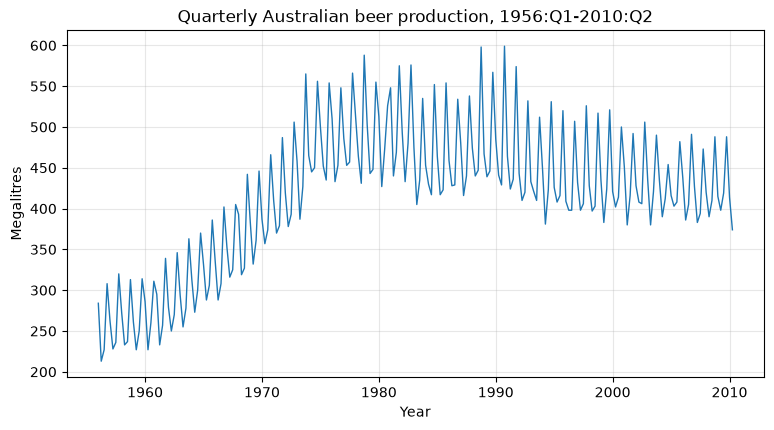

In [6]:
fig, ax = plt.subplots()

ax.plot(beer['date'], beer['value'], lw=1)
ax.set_title('Quarterly Australian beer production, 1956:Q1-2010:Q2')
ax.set_xlabel('Year'); ax.set_ylabel('Megalitres')

plt.savefig('assets/4.png', dpi=150, bbox_inches='tight')
plt.show()

**Part 2 - Overall Behaviour**

In [7]:
decade_means = (beer.assign(decade=(beer['year']//10)*10).groupby('decade')['value'].mean().round(1).reset_index().rename(columns={'value': 'mean_ML'}))

decade_means.to_csv('assets/5.csv', index=False)
decade_means

,decade,mean_ML
0,1950,261.6
1,1960,321.1
2,1970,461.8
3,1980,477.9
4,1990,449.2
5,2000,429.4
6,2010,394


**Part 3 - Seasonality**

In [8]:
seasonal_means = (beer.groupby('quarter')['value'].agg(['mean', 'std']).round(1).reset_index())
seasonal_means.to_csv('assets/6.csv', index=False)
seasonal_means

,quarter,mean,std
0,1,416.8,73.2
1,2,372.6,71.3
2,3,387.4,69.3
3,4,485.4,84


**Part 4 - Variability**

In [9]:
dec = beer.assign(decade=(beer['year']//10)*10).groupby(['decade','quarter'])['value'].mean().unstack()

dec['level'] = dec[[1,2,3,4]].mean(axis=1)
dec['range'] = dec[[1,2,3,4]].max(axis=1) - dec[[1,2,3,4]].min(axis=1)
dec['range_over_level'] = dec['range'] / dec['level']

dec_out = dec[['level', 'range', 'range_over_level']].round(3).reset_index()
dec_out.columns.name = None
dec_out.to_csv('assets/7.csv', index=False)
dec_out

,decade,level,range,range_over_level
0,1950,261.56,88.5,0.338
1,1960,321.12,102.9,0.32
2,1970,461.82,120.9,0.262
3,1980,477.9,128,0.268
4,1990,449.23,127.8,0.284
5,2000,429.38,94.4,0.22
6,2010,394,40,0.102


**Part 5 - Unusual Observations**

In [10]:
s = pd.Series(beer['value'].values, index=beer['date'])
resid = seasonal_decompose(s, model='additive', period=4).resid.dropna()
top = resid.abs().sort_values(ascending=False).head(6)

unusual = pd.DataFrame({
    'date': top.index.year.astype(str) + ' Q' + (((top.index.month - 1)//3) + 1).astype(str),
    'value': s[top.index].astype(int).values,
    'residual': resid[top.index].round(1).values
})

unusual.to_csv('assets/8.csv', index=False)
unusual

,date,value,residual
0,1981 Q1,548,49.6
1,1990 Q4,599,49
2,1988 Q4,598,41.2
3,1978 Q3,431,-38.5
4,1980 Q4,526,-38
5,1991 Q4,574,37.6


**Part 6 - Seasonal Plot**

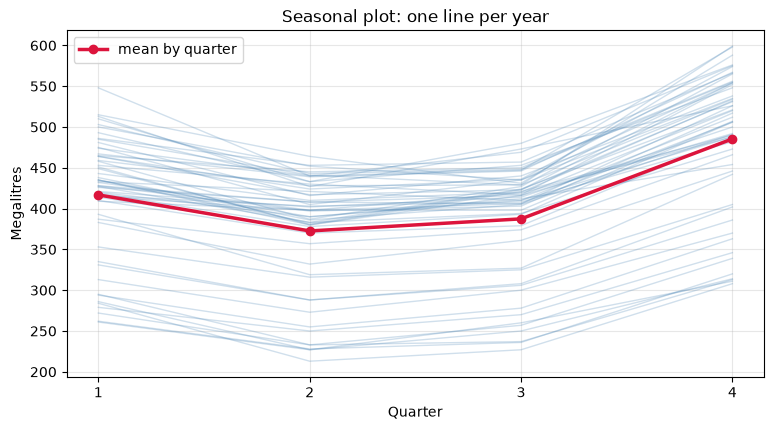

In [11]:
fig, ax = plt.subplots()
for yr, grp in beer.groupby('year'):
    grp = grp.sort_values('quarter')
    ax.plot(grp['quarter'], grp['value'], color='steelblue', alpha=0.25, lw=1)

ax.plot(seasonal_means['quarter'], seasonal_means['mean'], color='crimson', lw=2.5, marker='o', label='mean by quarter')
ax.set_xticks([1,2,3,4]); ax.set_xlabel('Quarter'); ax.set_ylabel('Megalitres')
ax.set_title('Seasonal plot: one line per year'); ax.legend()

plt.savefig('assets/9.png', dpi=150, bbox_inches='tight')
plt.show()

**Part 7 - Seasonal Subseries Plot**

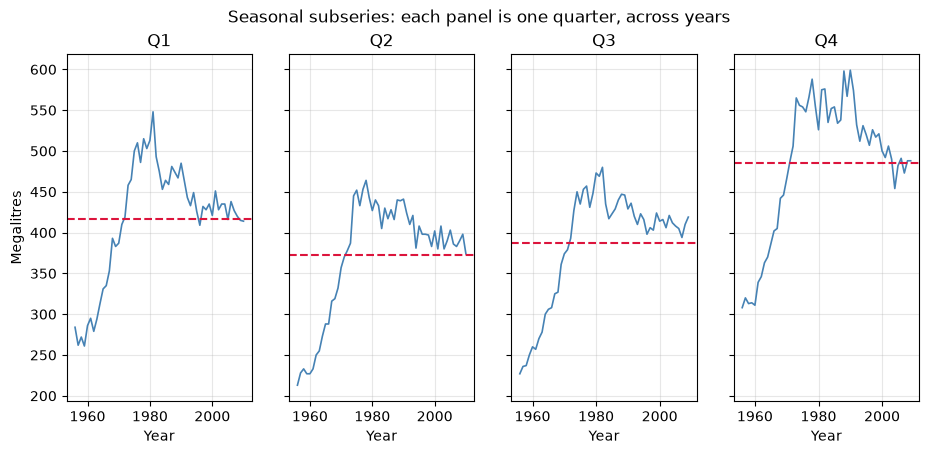

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(11, 4.5), sharey=True)

for q, ax in zip([1,2,3,4], axes):
    sub = beer[beer['quarter'] == q].sort_values('year')
    ax.plot(sub['year'], sub['value'], color='steelblue', lw=1.2)
    ax.axhline(sub['value'].mean(), color='crimson', ls='--', lw=1.5)
    ax.set_title(f'Q{q}'); ax.set_xlabel('Year')

axes[0].set_ylabel('Megalitres')
fig.suptitle('Seasonal subseries: each panel is one quarter, across years')

plt.savefig('assets/10.png', dpi=150, bbox_inches='tight')
plt.show()